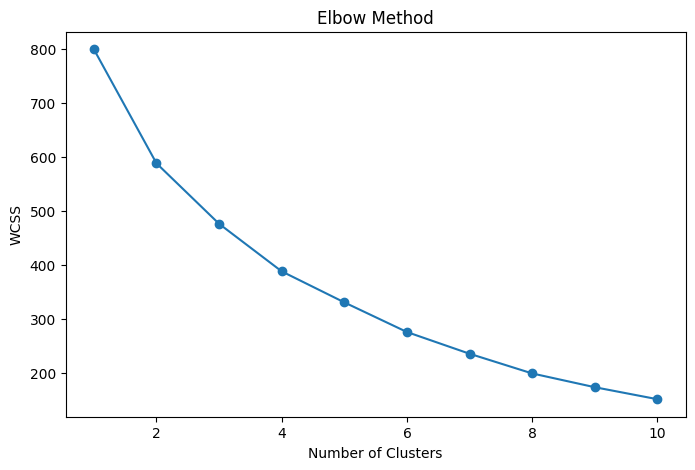

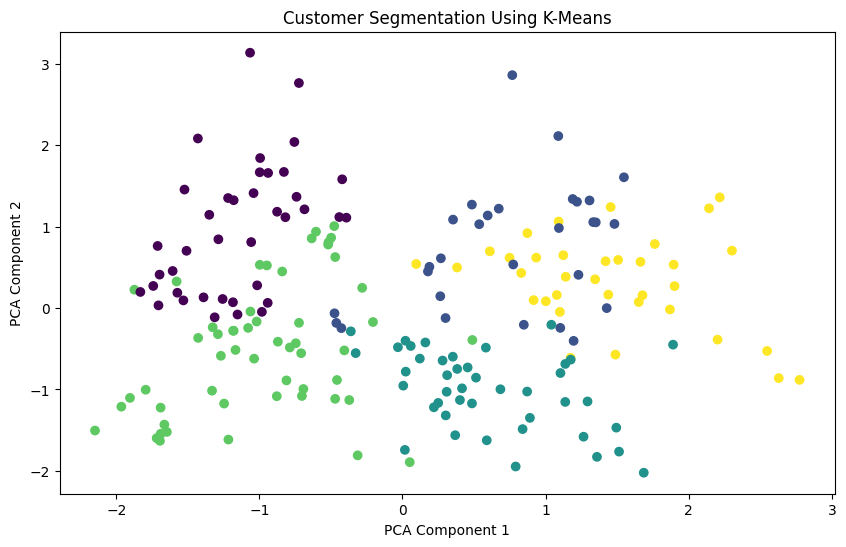


Cluster Summary
           Gender        Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                                    
0        0.538462  32.692308           86.538462               82.128205   
1        0.551724  36.482759           89.517241               18.000000   
2        1.000000  49.813953           49.232558               40.069767   
3        0.592593  24.907407           39.722222               61.203704   
4        0.000000  55.714286           53.685714               36.771429   

             PCA1      PCA2  
Cluster                      
0       -1.151299  0.959764  
1        0.739004  0.744866  
2        0.606362 -1.008718  
3       -0.992308 -0.501973  
4        1.456589  0.327129  

Total Customers in Each Cluster
Cluster
3    54
2    43
0    39
4    35
1    29
Name: count, dtype: int64
Predicted Cluster: 1


C:\Users\ASUS\PycharmProjects\1PythonProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = pd.read_csv("C:/Users/ASUS/Downloads/Mall_Customers.csv")

data = data.drop("CustomerID", axis=1)

data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})

x = data.copy()

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_scaled)

data["Cluster"] = clusters

pca = PCA(n_components=2)
pca_features = pca.fit_transform(x_scaled)

data["PCA1"] = pca_features[:, 0]
data["PCA2"] = pca_features[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(
    data["PCA1"],
    data["PCA2"],
    c=data["Cluster"]
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation Using K-Means")
plt.show()

cluster_summary = data.groupby("Cluster").mean()

print("\nCluster Summary")
print(cluster_summary)

print("\nTotal Customers in Each Cluster")
print(data["Cluster"].value_counts())

data.to_csv("clustered_customers.csv", index=False)

while True:
    age = float(input("Enter Age: "))
    gender = float(input("Enter Gender (0=Male, 1=Female): "))
    income = float(input("Enter Annual Income (k$): "))
    spending = float(input("Enter Spending Score (1-100): "))

    new_customer = np.array([[gender, age, income, spending]])

    new_customer_scaled = scaler.transform(new_customer)

    predicted_cluster = kmeans.predict(new_customer_scaled)

    print(f"Predicted Cluster: {predicted_cluster[0]}")

    choice = input("Predict another customer? (y/n): ")

    if choice.lower() != "y":
        break